# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Lab assignment №1, part 2
## Gradient boosting on temporal data and feature importances

Today we will work with Gradient Boosting library. It is one of the most popular models these days that shows both great quality and performance.

Choises for library are:

* [LightGBM](https://github.com/Microsoft/LightGBM) by Microsoft. Handful and fast.
* [Catboost](https://github.com/catboost/catboost) by Yandex. Tuned to deal well with categorical features.
* [xgboost](https://github.com/dmlc/xgboost) by dlmc. The most famous framework which got very popular on kaggle.

**Dataset**

By default we will work with widely known [Human Actividy Recognition (HAR) dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones). Data is available at UCI repository.

There are available both raw and preprocessed datasets. This time we will use the preprocessed one.
Some simple preprocessing is done for you.

If you want more interpretable data, you can take [Wine quality dataset](https://archive.ics.uci.edu/dataset/186/wine+quality) (see details below).

Your __ultimate target is to get familiar with one of the frameworks above__ and achieve at least 90% accuracy on test dataset and try to get some useful insights on the features the model paid attention to.

_Despite the main language of this notebook is English, feel free to write your thoughts in Russian._

In [ ]:
!pip install catboost



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 6.9 MB/s eta 0:00:00


In [ ]:
import catboost

## Part 0. Downloading and preprocessing

The preprocessing is done for you. Let's take a look at the data:

In [ ]:
# Download and unpack dataset from UCI
!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
!unzip -u "UCI HAR Dataset.zip" "UCI HAR Dataset/train/X_train.txt" "UCI HAR Dataset/train/y_train.txt" \
"UCI HAR Dataset/test/X_test.txt" "UCI HAR Dataset/test/y_test.txt" "UCI HAR Dataset/activity_labels.txt"

--2025-02-05 16:22:32--  https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘UCI HAR Dataset.zip’

UCI HAR Dataset.zip     [        <=>         ]  58.17M  35.7MB/s    in 1.6s    

2025-02-05 16:22:34 (35.7 MB/s) - ‘UCI HAR Dataset.zip’ saved [60999314]

Archive:  UCI HAR Dataset.zip
  inflating: UCI HAR Dataset/activity_labels.txt  
  inflating: UCI HAR Dataset/test/X_test.txt  
  inflating: UCI HAR Dataset/test/y_test.txt  
  inflating: UCI HAR Dataset/train/X_train.txt  
  inflating: UCI HAR Dataset/train/y_train.txt  


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
X_train = np.genfromtxt("UCI HAR Dataset/train/X_train.txt")
y_train = np.genfromtxt("UCI HAR Dataset/train/y_train.txt")
print(f"Train set: {X_train.shape}, {y_train.shape}")

X_test = np.genfromtxt("UCI HAR Dataset/test/X_test.txt")
y_test = np.genfromtxt("UCI HAR Dataset/test/y_test.txt")
print(f"Test set: {X_test.shape}, {y_test.shape}")

n_features = X_train.shape[1]

Train set: (7352, 561), (7352,)
Test set: (2947, 561), (2947,)


In [ ]:
activity_labels = {}
with open("UCI HAR Dataset/activity_labels.txt", "r") as file:
    for line in file:
        label, name = line.strip().split(" ")
        activity_labels[int(label)] = name

activity_labels

{1: 'WALKING',
 2: 'WALKING_UPSTAIRS',
 3: 'WALKING_DOWNSTAIRS',
 4: 'SITTING',
 5: 'STANDING',
 6: 'LAYING'}

Let's normalize data

In [ ]:
data_mean = X_train.mean(axis=0)
data_std = X_train.std(axis=0)

X_train = (X_train - data_mean) / data_std
X_test = (X_test - data_mean) / data_std

The dataset has some duplicating features. Let's remove them

In [ ]:
# fmt: off
duplicating_columns = (
    205, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 231, 244, 257, 507, 520, 533, 546,
)
# fmt: on

duplicating_mask = np.isin(range(n_features), duplicating_columns)

In [ ]:
X_train_unique = X_train[:, ~duplicating_mask]
X_test_unique = X_test[:, ~duplicating_mask]

X_train_unique.shape, X_test_unique.shape

((7352, 540), (2947, 540))

PCA could be useful in this case. E.g.

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(0.99)

X_train_pca = pca.fit_transform(X_train_unique)
X_test_pca = pca.transform(X_test_unique)

X_train_pca.shape, X_test_pca.shape

((7352, 179), (2947, 179))

<ipython-input-14-28acc3c89459>:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


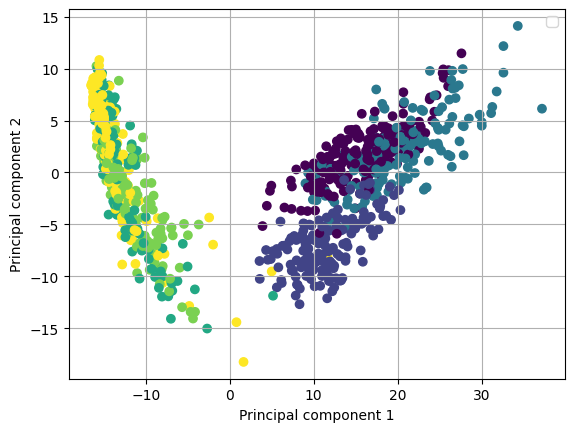

In [ ]:
plt.scatter(X_train_pca[:1000, 0], X_train_pca[:1000, 1], c=y_train[:1000])
plt.grid()
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.legend()

Text(0, 0.5, 'Principal component 5')

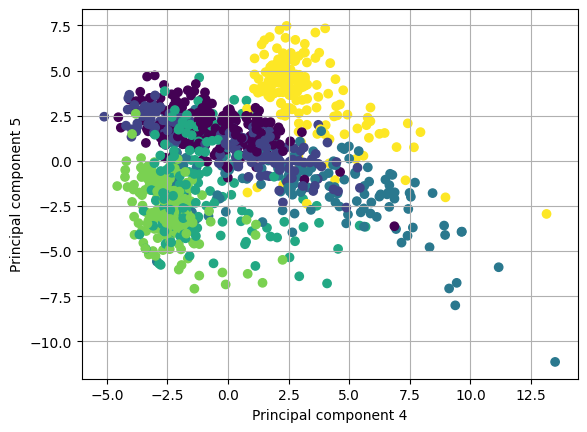

In [ ]:
plt.scatter(X_train_pca[:1000, 3], X_train_pca[:1000, 4], c=y_train[:1000])
plt.grid()
plt.xlabel("Principal component 4")
plt.ylabel("Principal component 5")

### Alternative dataset: Wine quality

Please, take this dataset if you are sure you can preprocess it yourself and ready to work with it's features and results, so it is done on your risk.

However you will have interpretable features which can be analysed with shap in last part

In [ ]:
!pip install ucimlrepo

In [ ]:
import ucimlrepo as uci

In [ ]:
dataset = uci.fetch_ucirepo(id=186)

print(dataset.metadata.name, '\n')
print(dataset.metadata.abstract, '\n')
print(dataset.metadata.additional_info.summary, '\n')

## Part 1. Fit the model.

Despite optimal parameters (e.g. for xgboost) can be found on the web, we still want you to approximate them by yourself.

In this part just check some (3-5) sets of hyperparameters by hand.

In [ ]:
# YOUR CODE HERE

# Example: https://rpubs.com/burakh/har_xgb

In [ ]:
train_data = X_train_pca
train_labels = y_train

test_data = X_test_pca
test_labels = y_test

In [ ]:
import numpy as np

from catboost import CatBoostClassifier

def try_params(
                           it=2,
                           h=2,
                           eta=1,
):
  model = CatBoostClassifier(iterations=it,
                           depth=h,
                           learning_rate=eta,
                           loss_function='MultiClass',
                           verbose=True)
  # train the model
  model.fit(train_data, train_labels)
  # make the prediction using the resulting model
  preds_class = model.predict(test_data)
  preds_proba = model.predict_proba(test_data)
  print("class = ", preds_class)
  print("proba = ", preds_proba)
  err = 0
  n = len(preds_class)
  for i in range(n):
    if test_labels[i] != preds_class[i][0]:
      err += 1
  print("err / n = ", err/n)
  print(dict(model.get_metadata())['training'])

In [ ]:
try_params()

0:	learn: 0.9910110	total: 40ms	remaining: 40ms
1:	learn: 0.8219137	total: 69.3ms	remaining: 0us
class =  [[4.]
 [4.]
 [4.]
 ...
 [3.]
 [3.]
 [1.]]
proba =  [[0.00921284 0.00826157 0.00799789 0.48919395 0.47195947 0.01337427]
 [0.00921284 0.00826157 0.00799789 0.48919395 0.47195947 0.01337427]
 [0.00921284 0.00826157 0.00799789 0.48919395 0.47195947 0.01337427]
 ...
 [0.18111348 0.16057246 0.61885412 0.01309634 0.01305703 0.01330657]
 [0.18111348 0.16057246 0.61885412 0.01309634 0.01305703 0.01330657]
 [0.87950622 0.07880438 0.02393397 0.00589581 0.00589777 0.00596184]]
err / n =  0.34441805225653205
{"metrics":{"learn_best_error":{"MultiClass":0.8219137009842136},"test_metrics_history":[],"learn_metrics_history":[{"MultiClass":0.9910109829768942},{"MultiClass":0.8219137009842136}],"test_best_error":[]}}


In [ ]:
try_params(
    it=6,
    h=2,
    eta=1,
)

0:	learn: 0.9910110	total: 40.4ms	remaining: 202ms
1:	learn: 0.8219137	total: 71.5ms	remaining: 143ms
2:	learn: 0.7218811	total: 101ms	remaining: 101ms
3:	learn: 0.6600318	total: 133ms	remaining: 66.3ms
4:	learn: 0.6107211	total: 160ms	remaining: 31.9ms
5:	learn: 0.5696312	total: 192ms	remaining: 0us
class =  [[5.]
 [5.]
 [5.]
 ...
 [1.]
 [1.]
 [1.]]
proba =  [[4.86066293e-03 1.37771727e-03 1.23394155e-03 1.03865867e-01
  8.86768031e-01 1.89378069e-03]
 [3.72632696e-03 4.99200836e-04 1.40461169e-03 2.65914248e-01
  7.27897566e-01 5.58046457e-04]
 [9.45298530e-03 9.00066639e-03 1.17344401e-02 2.26201606e-01
  7.41796849e-01 1.81345378e-03]
 ...
 [4.49069637e-01 1.55422488e-01 3.41554386e-01 1.35253461e-02
  3.79166347e-02 2.51150805e-03]
 [4.49069637e-01 1.55422488e-01 3.41554386e-01 1.35253461e-02
  3.79166347e-02 2.51150805e-03]
 [8.70899722e-01 8.28545952e-02 3.38887441e-02 2.63094856e-03
  8.94585328e-03 7.80137006e-04]]
err / n =  0.2517814726840855
{"metrics":{"learn_best_error":{

In [ ]:
try_params(
    it=10,
    h=6,
    eta=0.3
    ,
)

0:	learn: 1.1685758	total: 639ms	remaining: 5.75s
1:	learn: 0.9091955	total: 1.06s	remaining: 4.23s
2:	learn: 0.7651073	total: 1.48s	remaining: 3.44s
3:	learn: 0.6729246	total: 1.94s	remaining: 2.91s
4:	learn: 0.5997000	total: 2.4s	remaining: 2.4s
5:	learn: 0.5435621	total: 2.73s	remaining: 1.82s
6:	learn: 0.4985474	total: 2.97s	remaining: 1.27s
7:	learn: 0.4625908	total: 3.23s	remaining: 806ms
8:	learn: 0.4274054	total: 3.47s	remaining: 386ms
9:	learn: 0.4044939	total: 3.71s	remaining: 0us
class =  [[5.]
 [5.]
 [5.]
 ...
 [2.]
 [2.]
 [1.]]
proba =  [[0.01354441 0.014835   0.01271051 0.328635   0.60794331 0.02233177]
 [0.00797976 0.00817904 0.00803122 0.13232837 0.83041943 0.01306218]
 [0.00907522 0.01075165 0.01167384 0.12537596 0.8301626  0.01296072]
 ...
 [0.22346061 0.46752228 0.25040563 0.01842435 0.02152655 0.01866057]
 [0.13617008 0.53917301 0.25572259 0.02046569 0.02297416 0.02549447]
 [0.39332872 0.36829351 0.17650922 0.02023378 0.02288188 0.0187529 ]]
err / n =  0.18086189345

In [ ]:
# WHICH SET IS USED to COMPUTE LEARN?

In [ ]:
set(y_train)

{1.0, 2.0, 3.0, 4.0, 5.0, 6.0}

In [ ]:
dict(model.get_metadata())['training']

'{"metrics":{"learn_best_error":{"MultiClass":0.8219137009842136},"test_metrics_history":[],"learn_metrics_history":[{"MultiClass":0.9910109829768942},{"MultiClass":0.8219137009842136}],"test_best_error":[]}}'

## Part 2. Use hyper parameter tuning system

Use [optuna](https://optuna.org/) or [hyperopt](http://hyperopt.github.io/hyperopt/) zero order optimizer to find optimal hyper param set.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.4/383.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 6.1 MB/s eta 0:00:00


In [ ]:
import optuna

### Conclusion

Please, write down your thoughts on the experiment results:

...

## Part 3. Interpret the model predictions

Train model on original feature set and analyze it.

Please use [shap](https://github.com/slundberg/shap) to build beeswarm plot and at least one of your choice and interpret them (write conclusion).

Explanations of features can be found on dataset's UCI page (see dataset downloading section).

In [ ]:
import shap  # noqa: F401


# YOUR CODE HERE

### Conclusion

Your thoughts about the plots and model behaviour:

...